# Reproducible Visualization of Model Evaluation and Interpretability Analyses

This tutorial provides a **fully reproducible, modular visualization pipeline** for evaluating model performance, robustness, and interpretability in RNA–protein interaction studies. 

## Contents Overview

### 4. Impact of task adaptation
- Scatter plots featuring:
  - Diagonal reference line.
  - Marginal density distributions (densigrams).
- Separate regression plots displaying:
  - Pearson correlation.
  - Explicit annotation of R and P values.
- Designed to visually assess **global performance shifts**.

```{note}
Please download the pre-computed results from `Figshare` first, and place them in the expected directory.
```

## Impact of task adaptation

```{note}
Plot "Pre-training vs Fine-tuning" performance:
1) Scatter plot with diagonal y=x and marginal densigram (density+hist on margins)
2) Scatter plot with linear regression line + Pearson correlation annotation

Input CSV format

density.csv must contain at least two numeric columns:
- pretrained  : pre-training scores
- finetuning  : fine-tuning scores
```

In [1]:
library(ggExtra)   # ggMarginal for densigram
library(ggplot2)

In [ ]:
# Paths -------------------------------------------------------------------
csv_path <- "../ablation&interpretability/density.csv"
out_dir  <- "./"

# Global style -------------------------------------------------------------
point_col <- "red"
point_alpha <- 0.4

xlim <- c(0.5, 1.0)
ylim <- c(0.5, 1.0)


In [3]:
# Read data ---------------------------------------------------------------
sample_data <- read.csv(csv_path)

# Basic validation --------------------------------------------------------
required_cols <- c("pretrained", "finetuning")
missing <- setdiff(required_cols, names(sample_data))
if (length(missing) > 0) {
  stop("Missing required columns: ", paste(missing, collapse = ", "))
}

# Ensure numeric (protect against accidental character columns)
sample_data$pretrained <- as.numeric(sample_data$pretrained)
sample_data$finetuning <- as.numeric(sample_data$finetuning)

# Preview
head(sample_data)


,pretrained,finetuning
,<dbl>,<dbl>
1,0.7986,0.7972
2,0.8331,0.8716
3,0.8024,0.8284
4,0.8459,0.8730
5,0.8372,0.8502
6,0.9288,0.9459


In [4]:
plot_scatter_with_densigram <- function(
  df,
  x_col = "pretrained",
  y_col = "finetuning",
  xlim = c(0.5, 1),
  ylim = c(0.5, 1),
  point_col = "red",
  point_alpha = 0.4,
  point_size = 3,
  diag_alpha = 0.8,
  annotate_title = "Average area under ROC",
  annotate_lines = c("Pre-training: 0.8723", "Fine-tuning: 0.8873"),
  annotate_pos = list(title = c(0.72, 0.99), line1 = c(0.9, 0.53), line2 = c(0.9, 0.50)),
  marginal_type = "densigram"
) {
  #' Scatter plot with y=x diagonal and marginal densigram.
  #'
  #' Parameters
  #' ----------
  #' df : data.frame
  #'   Must contain columns x_col and y_col (numeric).
  #' x_col, y_col : character
  #'   Column names for x and y.
  #' xlim, ylim : numeric length-2
  #'   Axis limits.
  #' point_col : character
  #'   Point (and marginal) color.
  #' annotate_title : character
  #'   Title text shown inside plot.
  #' annotate_lines : character vector (length 2)
  #'   Additional annotation lines.
  #' annotate_pos : list
  #'   Coordinates for annotation texts.
  #' marginal_type : character
  #'   Passed to ggExtra::ggMarginal type. e.g. "densigram", "density", "histogram".
  #'
  #' Returns
  #' -------
  #' A ggExtra object (can be printed/saved by ggsave).

  base <- ggplot(df, aes(x = .data[[x_col]], y = .data[[y_col]])) +
    theme_minimal() +
    geom_point(size = point_size, alpha = point_alpha, color = point_col) +
    geom_abline(intercept = 0, slope = 1, colour = point_col, alpha = diag_alpha) +
    scale_x_continuous(limits = xlim) +
    scale_y_continuous(limits = ylim) +
    xlab("") + ylab("") +
    theme(
      legend.position = "none",
      axis.line = element_line(linewidth = 1, colour = "black"),
      panel.grid.major = element_blank(),
      panel.grid.minor = element_blank(),
      panel.border = element_blank(),
      panel.background = element_blank(),
      axis.text.x = element_text(size = 20, colour = "black"),
      axis.text.y = element_text(size = 20, colour = "black")
    ) +
    annotate("text", x = annotate_pos$title[1], y = annotate_pos$title[2],
             label = annotate_title, size = 8, colour = "black") +
    annotate("text", x = annotate_pos$line1[1], y = annotate_pos$line1[2],
             label = annotate_lines[1], size = 7, colour = "black") +
    annotate("text", x = annotate_pos$line2[1], y = annotate_pos$line2[2],
             label = annotate_lines[2], size = 7, colour = "black")

  ggExtra::ggMarginal(
    base,
    type = marginal_type,
    colour = point_col,
    alpha = point_alpha,
    fill = point_col
  )
}


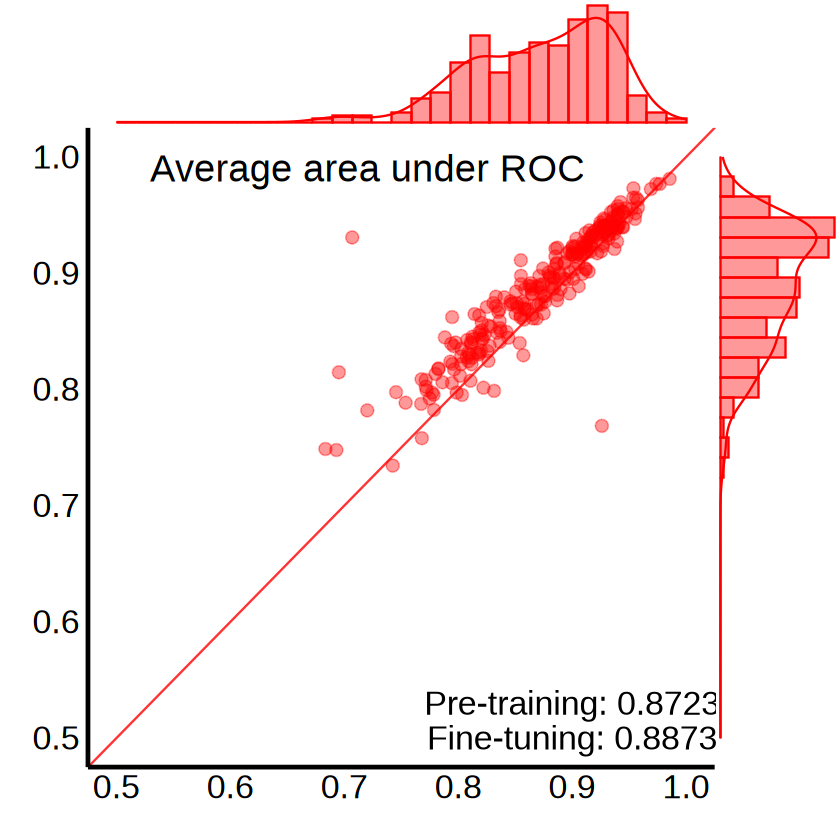

In [5]:
p_densigram <- plot_scatter_with_densigram(
  df = sample_data,
  xlim = xlim,
  ylim = ylim,
  point_col = point_col,
  point_alpha = point_alpha
)

print(p_densigram)

ggsave(
  filename = file.path(out_dir, "density.pdf"),
  plot = p_densigram,
  width = 8, height = 8, dpi = 300
)


In [6]:
plot_pearson_regression <- function(
  df,
  x_col = "pretrained",
  y_col = "finetuning",
  point_col = "red",
  point_alpha = 0.4,
  point_size = 5,
  label_pos = c(0.85, 0.80),  # x,y position of annotation text
  label_size = 20
) {
  #' Scatter + linear regression + Pearson correlation annotation.
  #'
  #' Parameters
  #' ----------
  #' df : data.frame
  #' x_col, y_col : character
  #' point_col : character
  #' label_pos : numeric length-2
  #'   Position for the Pearson text annotation.
  #'
  #' Returns
  #' -------
  #' List with:
  #' - plot: ggplot object
  #' - cor : cor.test result
  
  x <- df[[x_col]]
  y <- df[[y_col]]
  
  cor_res <- cor.test(x, y, method = "pearson")
  p_value_rounded <- round(cor_res$p.value, 3)
  r_rounded <- round(unname(cor_res$estimate), 3)
  
  p <- ggplot(df, aes(x = .data[[x_col]], y = .data[[y_col]])) +
    geom_point(color = point_col, alpha = point_alpha, size = point_size) +
    geom_smooth(method = "lm", color = point_col, alpha = point_alpha, se = FALSE) +
    labs(x = "Pre-training", y = "Fine-tuning") +
    annotate(
      "text",
      x = label_pos[1], y = label_pos[2],
      label = paste0("Pearson\nR = ", r_rounded, "\nP = ", p_value_rounded),
      size = label_size / 10  # ggplot 'size' is not pt; scale down
    ) +
    theme_minimal() +
    theme(
      panel.background = element_blank(),
      panel.grid.major = element_blank(),
      panel.grid.minor = element_blank(),
      panel.border = element_rect(colour = "black", fill = NA, linewidth = 1),
      axis.line = element_line(colour = "black"),
      axis.ticks = element_line(colour = "black"),
      axis.title.x = element_text(margin = margin(t = 10)),
      axis.title.y = element_text(margin = margin(r = 10)),
      axis.title = element_text(size = 26),
      axis.text  = element_text(size = 24),
      plot.title = element_text(hjust = 0.5, size = 28)
    )
  
  list(plot = p, cor = cor_res)
}


`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'



	Pearson's product-moment correlation

data:  x and y
t = 36.695, df = 260, p-value < 2.2e-16
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.8934501 0.9331651
sample estimates:
      cor 
0.9155108 


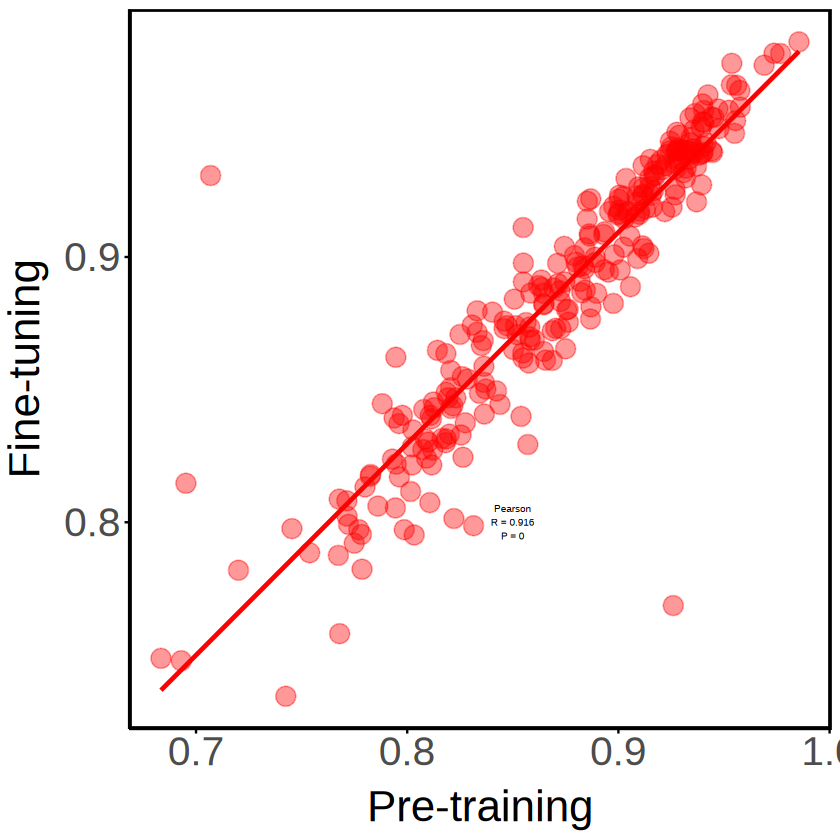

In [7]:
res <- plot_pearson_regression(
  df = sample_data,
  point_col = point_col,
  point_alpha = point_alpha,
  label_pos = c(0.85, 0.80),
  label_size = 20
)

p_inner <- res$plot
print(p_inner)

ggsave(
  filename = file.path(out_dir, "density_inner.pdf"),
  plot = p_inner,
  width = 7, height = 7.5, dpi = 300
)

# Optional: print the exact correlation test result in notebook
res$cor
